# PubChem loader statistics

This notebook explores the local `PubChemAssayLoader` catalog and draws a few dataset-level and graph-level statistics. It is intended as a quick inspection workflow before choosing an assay for downstream modeling.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from abstractgraph_graphicalizer.chem import PubChemAssayLoader


## Catalog overview

`PubChemAssayLoader.list_assays()` already exposes file sizes and molecule counts for each paired active/inactive assay export. We convert those summaries into a dataframe first.


In [3]:
loader = PubChemAssayLoader(on_error="skip")
summaries = loader.list_assays()

if not summaries:
    raise FileNotFoundError(f"No paired PubChem assay exports found under {loader.root}")

assay_table = pd.DataFrame(
    {
        "assay_id": summary.assay_id,
        "active_molecule_count": summary.active_molecule_count,
        "inactive_molecule_count": summary.inactive_molecule_count,
        "total_molecule_count": summary.total_molecule_count,
        "active_size_mb": summary.active_size_bytes / 1024 / 1024,
        "inactive_size_mb": summary.inactive_size_bytes / 1024 / 1024,
        "total_size_mb": summary.total_size_bytes / 1024 / 1024,
        "active_fraction": summary.active_molecule_count / summary.total_molecule_count,
        "inactive_fraction": summary.inactive_molecule_count / summary.total_molecule_count,
    }
    for summary in summaries
).sort_values(["total_molecule_count", "assay_id"], ascending=[False, True]).reset_index(drop=True)

print("root:", loader.root)
display(assay_table.head(10))
assay_table.describe(include="all").transpose()


root: /home/fabrizio/code/abstractgraph-ecosystem/repos/abstractgraph-graphicalizer/data/PUBCHEM


,assay_id,active_molecule_count,inactive_molecule_count,total_molecule_count,active_size_mb,inactive_size_mb,total_size_mb,active_fraction,inactive_fraction
0,463230,1675,666,2341,10.674005,3.897969,14.571974,0.715506,0.284494
1,492952,1453,841,2294,7.882731,4.467299,12.350030,0.633391,0.366609
2,588350,1232,634,1866,7.052930,4.116718,11.169648,0.660236,0.339764
3,651741,498,965,1463,2.316354,3.864491,6.180845,0.340396,0.659604
4,624249,355,173,528,2.529961,1.229708,3.759668,0.672348,0.327652
5,2631,273,97,370,1.646733,0.569281,2.216014,0.737838,0.262162


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
assay_id,6,6,463230,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
active_molecule_count,6.0,NaN,NaN,NaN,914.333333,611.094646,273.0,390.75,865.0,1397.75,1675.0
inactive_molecule_count,6.0,NaN,NaN,NaN,562.666667,353.211929,97.0,288.25,650.0,797.25,965.0
total_molecule_count,6.0,NaN,NaN,NaN,1477.0,859.249905,370.0,761.75,1664.5,2187.0,2341.0
active_size_mb,6.0,NaN,NaN,NaN,5.350452,3.702149,1.646733,2.369756,4.791445,7.675281,10.674005
inactive_size_mb,6.0,NaN,NaN,NaN,3.024244,1.672873,0.569281,1.888404,3.88123,4.062031,4.467299
total_size_mb,6.0,NaN,NaN,NaN,8.374697,5.021197,2.216014,4.364963,8.675247,12.054935,14.571974
active_fraction,6.0,NaN,NaN,NaN,0.626619,0.145232,0.340396,0.640103,0.666292,0.704717,0.737838
inactive_fraction,6.0,NaN,NaN,NaN,0.373381,0.145232,0.262162,0.295283,0.333708,0.359897,0.659604


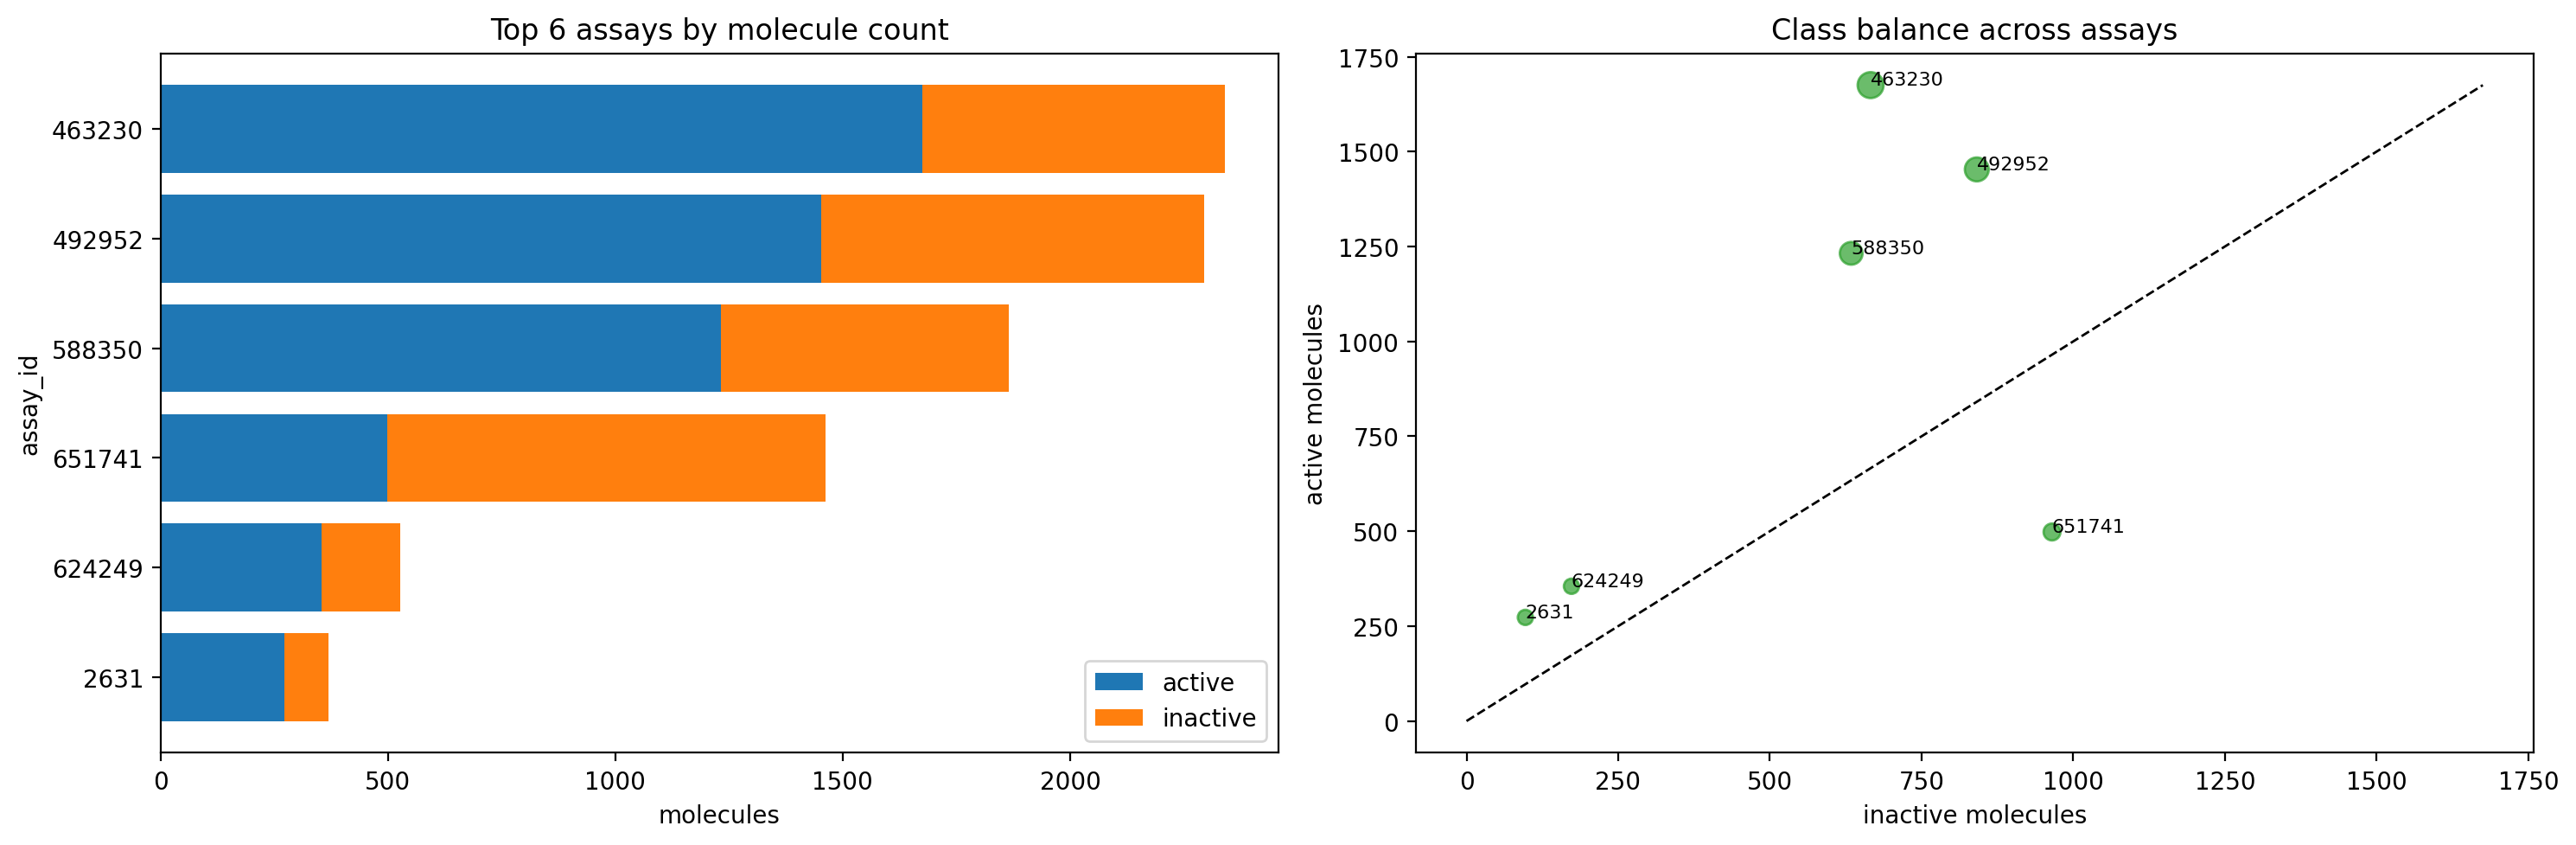

In [4]:
top_n = min(12, len(assay_table))
plot_table = assay_table.head(top_n).sort_values("total_molecule_count")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(plot_table["assay_id"], plot_table["active_molecule_count"], label="active", color="#1f77b4")
axes[0].barh(
    plot_table["assay_id"],
    plot_table["inactive_molecule_count"],
    left=plot_table["active_molecule_count"],
    label="inactive",
    color="#ff7f0e",
)
axes[0].set_title(f"Top {top_n} assays by molecule count")
axes[0].set_xlabel("molecules")
axes[0].set_ylabel("assay_id")
axes[0].legend()

axes[1].scatter(
    assay_table["inactive_molecule_count"],
    assay_table["active_molecule_count"],
    s=np.clip(assay_table["total_size_mb"] * 8, 40, 300),
    alpha=0.7,
    color="#2ca02c",
)
limits = [0, max(assay_table["inactive_molecule_count"].max(), assay_table["active_molecule_count"].max())]
axes[1].plot(limits, limits, linestyle="--", color="black", linewidth=1)
axes[1].set_title("Class balance across assays")
axes[1].set_xlabel("inactive molecules")
axes[1].set_ylabel("active molecules")

for _, row in assay_table.head(min(8, len(assay_table))).iterrows():
    axes[1].annotate(row["assay_id"], (row["inactive_molecule_count"], row["active_molecule_count"]), fontsize=8)

plt.tight_layout()


## Load one assay and inspect graph statistics

By default the notebook uses the largest assay currently available. You can override `assay_id` or the per-class limits below if you want a smaller slice.


In [5]:
assay_id = assay_table.loc[0, "assay_id"]
limit_active = 500
limit_inactive = 500

active_graphs, inactive_graphs = loader.load_split(
    assay_id,
    limit_active=limit_active,
    limit_inactive=limit_inactive,
)

print("assay_id:", assay_id)
print("active graphs  :", len(active_graphs))
print("inactive graphs:", len(inactive_graphs))


assay_id: 463230
active graphs  : 500
inactive graphs: 500


In [6]:
graphs = active_graphs + inactive_graphs
labels = ["active"] * len(active_graphs) + ["inactive"] * len(inactive_graphs)

graph_stats = pd.DataFrame(
    {
        "activity": labels,
        "node_count": [graph.number_of_nodes() for graph in graphs],
        "edge_count": [graph.number_of_edges() for graph in graphs],
    }
)
graph_stats["average_degree"] = 2.0 * graph_stats["edge_count"] / graph_stats["node_count"].clip(lower=1)
graph_stats["density"] = 2.0 * graph_stats["edge_count"] / (
    graph_stats["node_count"] * (graph_stats["node_count"] - 1)
).where(graph_stats["node_count"] > 1, 1)

display(graph_stats.head())
graph_stats.groupby("activity").agg(["mean", "median", "min", "max"])


,activity,node_count,edge_count,average_degree,density
0,active,29,31,2.137931,0.076355
1,active,26,28,2.153846,0.086154
2,active,23,25,2.173913,0.098814
3,active,22,23,2.090909,0.099567
4,active,27,30,2.222222,0.085470


node_count                edge_count                average_degree  \
               mean median min max       mean median min max           mean   
activity                                                                      
active       26.472   26.0  14  42     28.652   29.0  13  46       2.163525   
inactive     24.134   24.0  11  40     26.186   26.0  11  45       2.165781   

                                         density                                
            median       min       max      mean    median       min       max  
activity                                                                        
active    2.153846  1.857143  2.333333  0.087577  0.083205  0.053426  0.152381  
inactive  2.166667  1.900000  2.347826  0.098539  0.094203  0.057692  0.200000

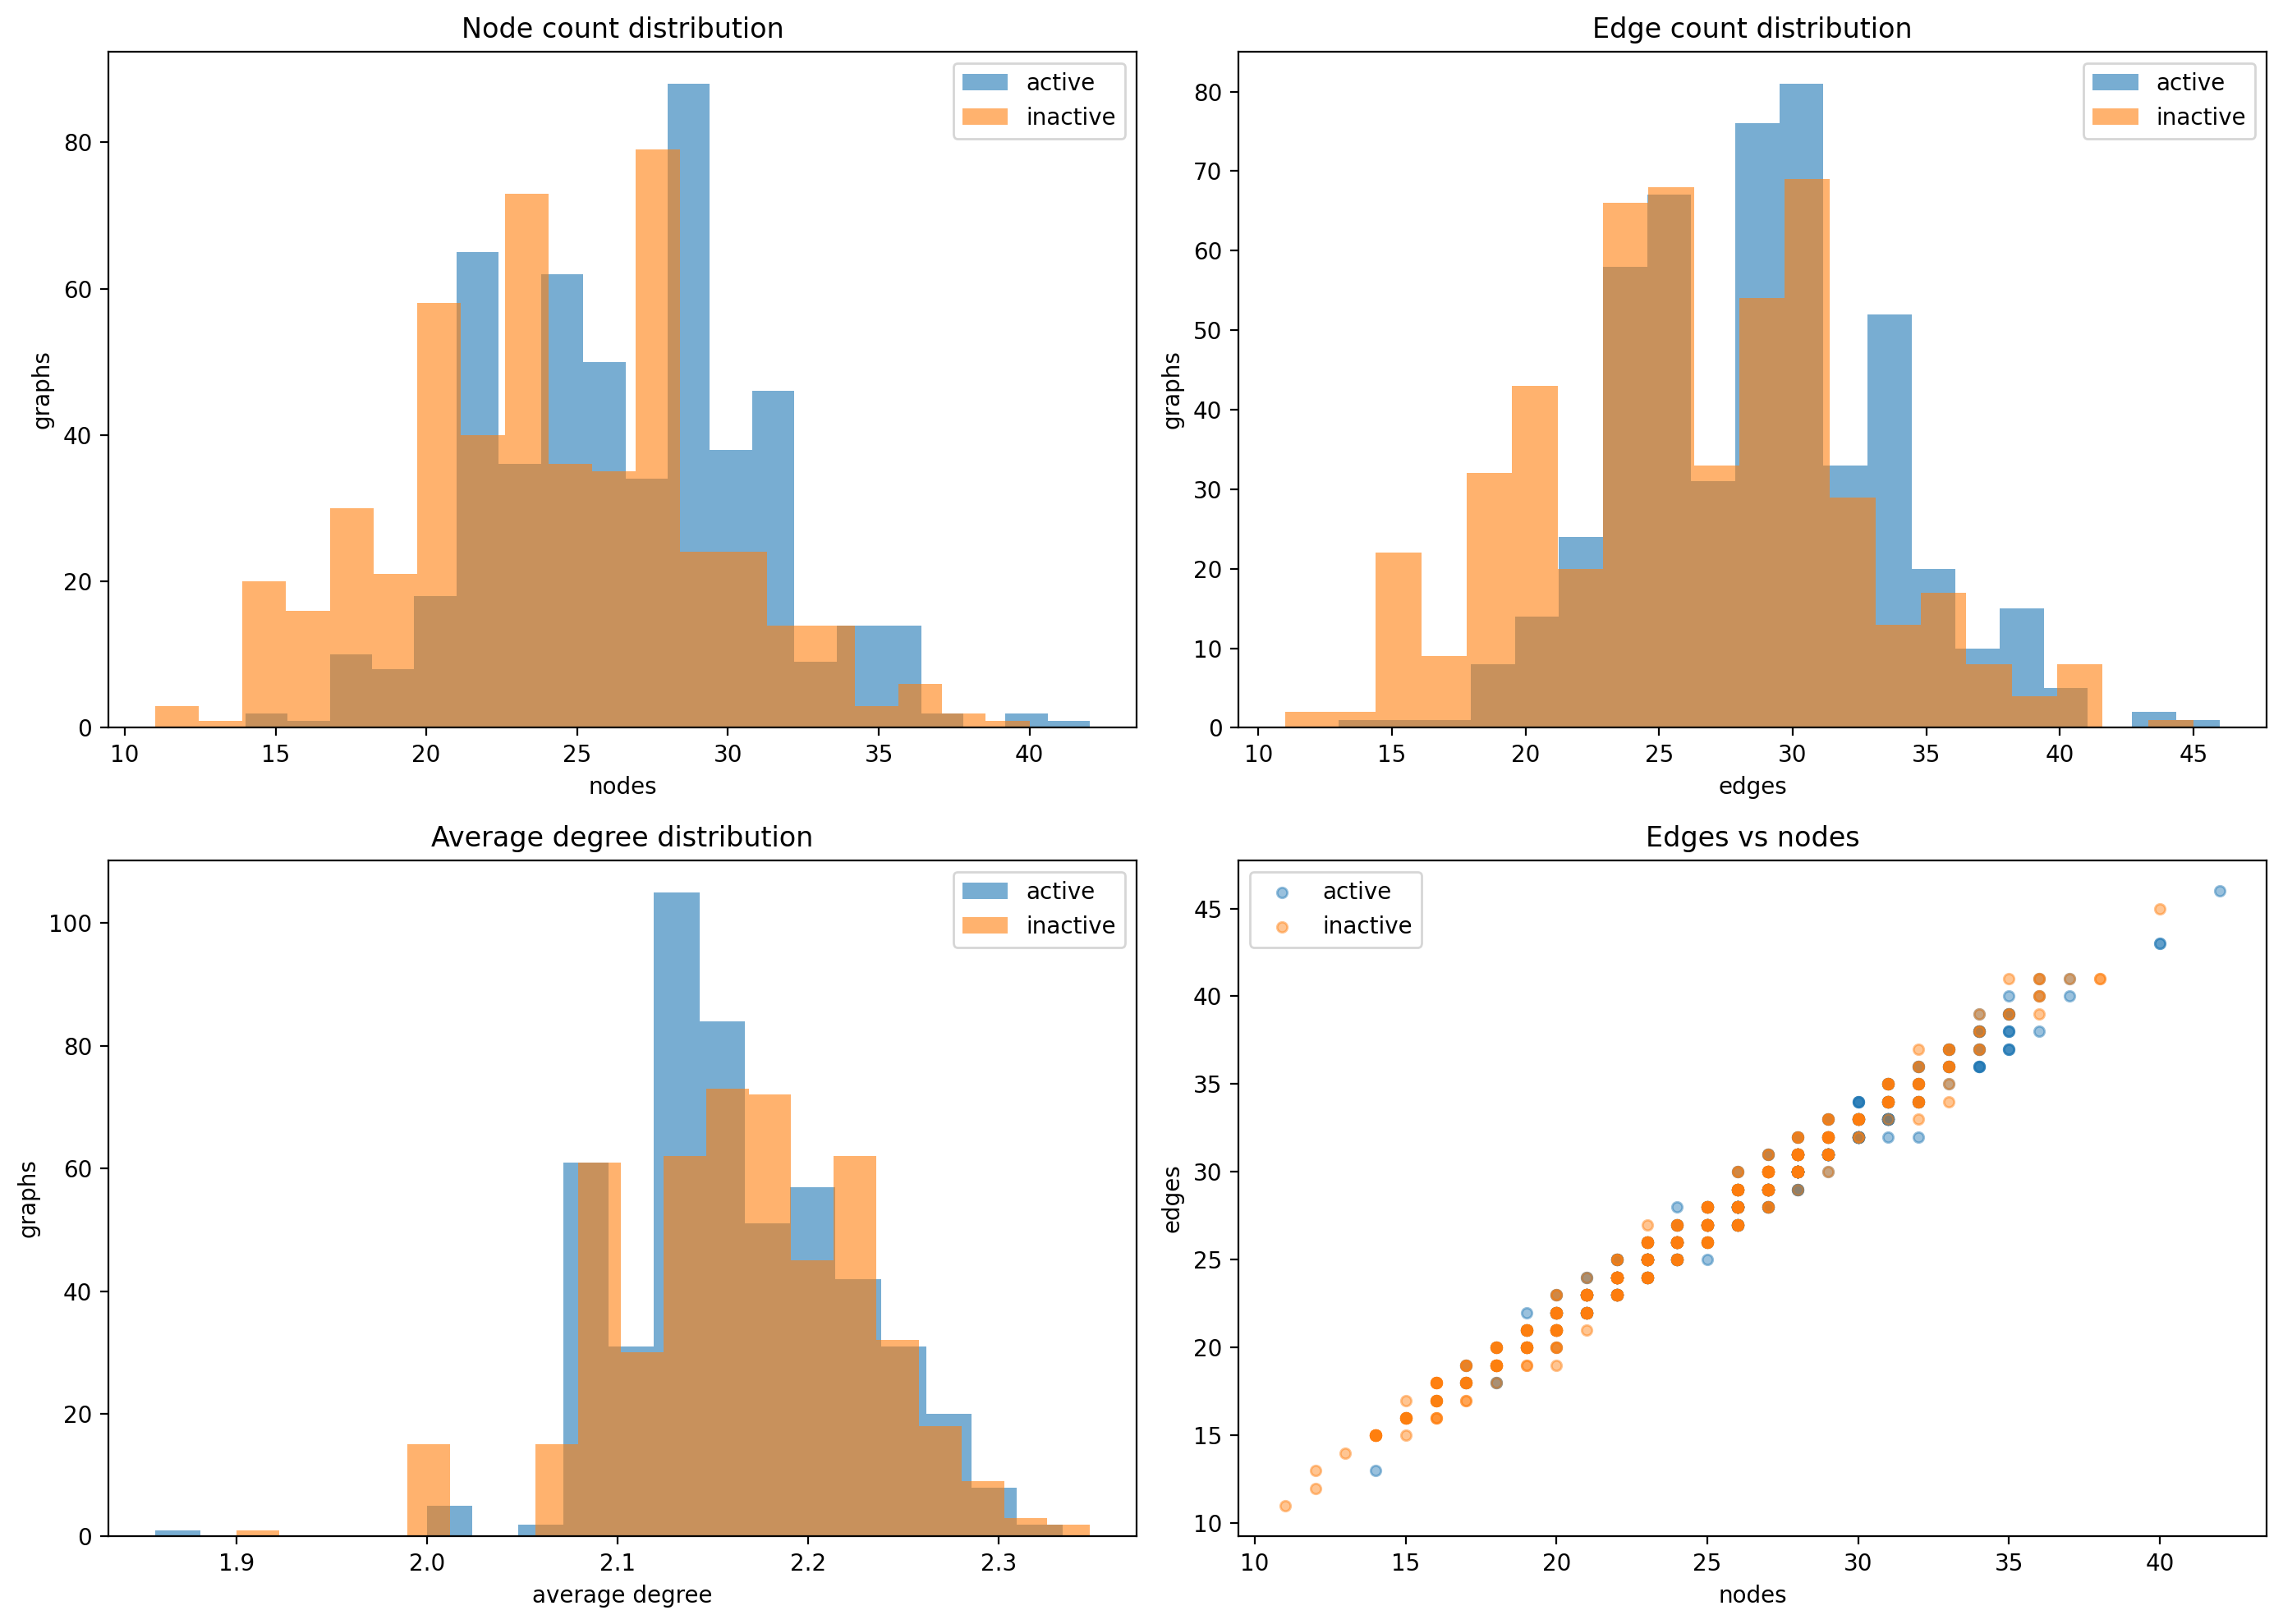

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for label, color in (("active", "#1f77b4"), ("inactive", "#ff7f0e")):
    subset = graph_stats.loc[graph_stats["activity"] == label]
    axes[0, 0].hist(subset["node_count"], bins=20, alpha=0.6, label=label, color=color)
    axes[0, 1].hist(subset["edge_count"], bins=20, alpha=0.6, label=label, color=color)
    axes[1, 0].hist(subset["average_degree"], bins=20, alpha=0.6, label=label, color=color)
    axes[1, 1].scatter(subset["node_count"], subset["edge_count"], alpha=0.45, s=20, label=label, color=color)

axes[0, 0].set_title("Node count distribution")
axes[0, 0].set_xlabel("nodes")
axes[0, 0].set_ylabel("graphs")

axes[0, 1].set_title("Edge count distribution")
axes[0, 1].set_xlabel("edges")
axes[0, 1].set_ylabel("graphs")

axes[1, 0].set_title("Average degree distribution")
axes[1, 0].set_xlabel("average degree")
axes[1, 0].set_ylabel("graphs")

axes[1, 1].set_title("Edges vs nodes")
axes[1, 1].set_xlabel("nodes")
axes[1, 1].set_ylabel("edges")

for axis in axes.ravel()[:3]:
    axis.legend()
axes[1, 1].legend()

plt.tight_layout()


In [8]:
summary = (
    graph_stats.groupby("activity")
    .agg(
        graphs=("activity", "size"),
        mean_nodes=("node_count", "mean"),
        median_nodes=("node_count", "median"),
        mean_edges=("edge_count", "mean"),
        median_edges=("edge_count", "median"),
        mean_density=("density", "mean"),
    )
    .round(3)
)

summary


,graphs,mean_nodes,median_nodes,mean_edges,median_edges,mean_density
activity,,,,,,
active,500,26.472,26.0,28.652,29.0,0.088
inactive,500,24.134,24.0,26.186,26.0,0.099
